# 1. Install necessary Libraries
**Ultimate Experiment Script — All Techniques with Toggle Flags**

In this part, we'll begin by installing necessary libraries needed for running our computer vision training and testing scripts\
**(NOTE): NO NEED TO RERUN THIS CELL EVEN IF SERVER RESTARTS**, as the libraries are stored inside VM boot disk and will not be removed

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
%pip install transformers scikit-learn pillow pandas numpy matplotlib huggingface_hub ipywidgets opencv-python google-cloud-storage

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# 2. Download Dataset From Storage Bucket to Jupyter Server
This is to reduce continuous Read/Write Call from Storage Bucket and reduce cost.\
**(Note): RUN THIS CELL ONCE ONLY EVEN IF SERVER RESTARTS.** This is because the dataset is stored locally in Jupyter Server and will remain even if server restart.\
Running multiple times may result in the 4939 images downloaded multiple times

In [2]:
from google.cloud import storage
import os

client = storage.Client()
bucket = client.bucket('naic-dataset-images')

# 1. Create the local directory
os.makedirs('dataset/image', exist_ok=True)

# 2. Download labels.csv permanently to the local disk
print("Fetching labels.csv...")
blob_csv = bucket.blob('labels.csv')
blob_csv.download_to_filename('dataset/labels.csv')
print("✅ labels.csv saved to dataset/labels.csv")

# 3. Download the images
blobs = bucket.list_blobs(prefix='image/')
print("\nStarting image download...")

download_count = 0
for i, blob in enumerate(blobs):
    if not blob.name.endswith('/'):
        filename = blob.name.split('/')[-1]
        local_path = f'dataset/image/{filename}'

        if not os.path.exists(local_path):
            blob.download_to_filename(local_path)
            download_count += 1

    if i % 500 == 0:
        print(f"Scanned {i} files...")

print(f"✅ Download complete! Fetched {download_count} new images. L4 GPU is ready to work.")

Fetching labels.csv...
✅ labels.csv saved to dataset/labels.csv

Starting image download...
Scanned 0 files...
Scanned 500 files...
Scanned 1000 files...
Scanned 1500 files...
Scanned 2000 files...
Scanned 2500 files...
Scanned 3000 files...
Scanned 3500 files...
Scanned 4000 files...
Scanned 4500 files...
✅ Download complete! Fetched 0 new images. L4 GPU is ready to work.


# 3. Read CSV File from Storage Bucket
In this part, since we need to create a variable df using pandas to load the csv file, we should separate this part from downloading part as variable is voilatile and will be reset every time kernel/server restarts

In [3]:
import pandas as pd

# Read the CSV directly from the VM's high-speed local disk
df = pd.read_csv('dataset/labels.csv')

print(f"Ready to train with {len(df)} images on local disk.")

Ready to train with 4939 images on local disk.


# 4. CLAHE Data Preprocessing + Retina Cropping
In this part, we'll write Contrast Limited Adaptive Histogram Equalization (CLAHE) preprocessing function logic, which is used to enhance the blurry dataset images to enable clearer image and allow small pixels to be detected. Besides that, we also implemented retina cropping to determine the eye fundus pixels more accurately

In [4]:
import cv2
import numpy as np
from PIL import Image

def crop_fundus(image, tol=10):
    """
    Removes the useless black borders around the circular fundus image.
    tol: Tolerance for black pixels (values below 10 are considered background).
    """
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Convert to grayscale to easily separate the eye from the background
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Create a mask of all pixels brighter than the tolerance
    mask = gray > tol

    # Get the coordinates of the actual eyeball
    coords = np.argwhere(mask)

    # Safety check: if the image is completely black, return the original
    if coords.size == 0:
        return image

    # Find the bounding box (min and max Y, min and max X)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1 # +1 to include the last pixel

    # Crop the image using numpy slicing
    cropped = image[y0:y1, x0:x1]

    return cropped

def preprocess_fundus(image):
    """
    The ultimate medical preprocessing pipeline.
    1. Tight crop the retina.
    2. Apply Green Channel CLAHE.
    """
    # Step 1: Remove black borders
    cropped_img = crop_fundus(image)

    # Step 2: Split into R, G, B channels
    r, g, b = cv2.split(cropped_img)

    # Step 3: Apply Green Channel CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_enhanced = clahe.apply(g)

    # Step 4: Merge and return as PIL Image for PyTorch
    enhanced = cv2.merge((r, g_enhanced, b))
    return Image.fromarray(enhanced)

# 5. Preprocessed vs Processed Image Visualization Comparison
In this part, we'll run a script to compare the dataset images before and after preprocessing to see if it's successful and fulfills our requirements

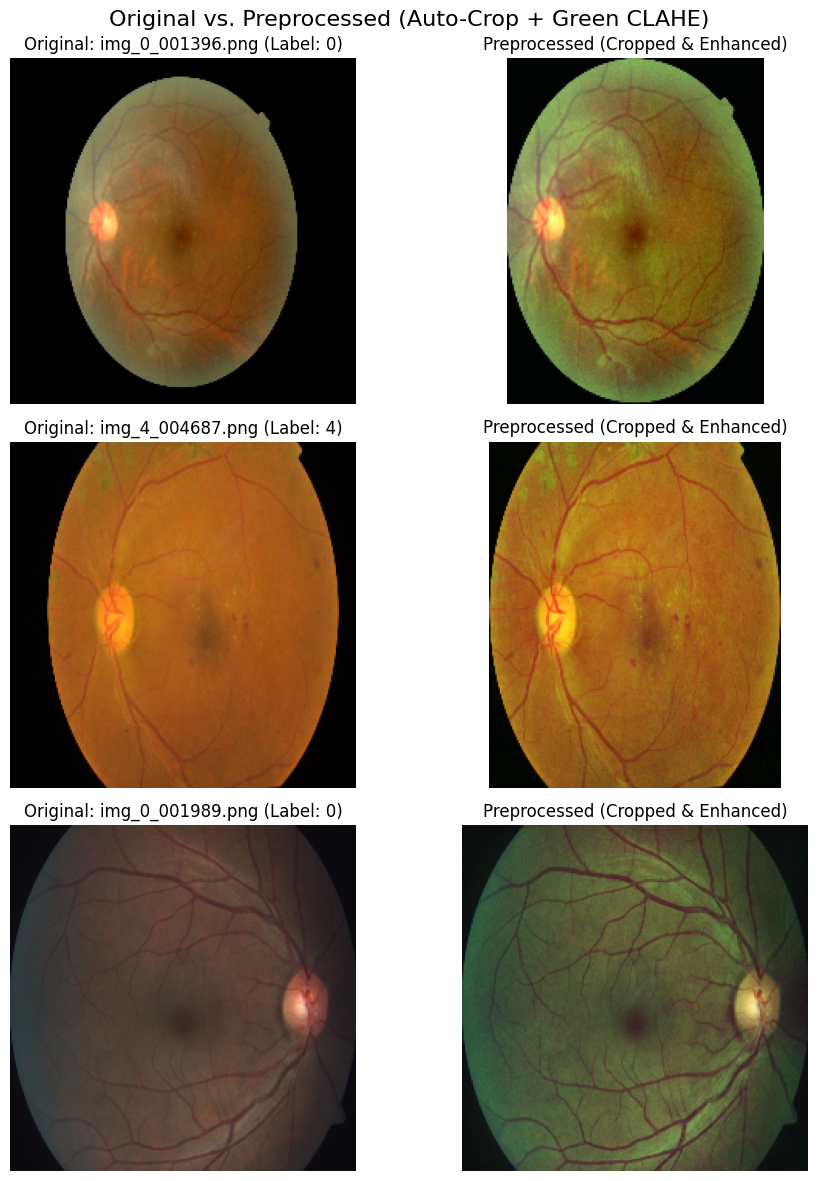

In [5]:
import matplotlib.pyplot as plt

def display_preprocessing_samples(dataframe, img_directory, num_samples=3):
    """
    Randomly samples images from the dataframe and displays a side-by-side
    comparison of the original vs. preprocessed images.
    """
    # Take random samples from the dataframe
    samples = dataframe.sample(n=num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    fig.suptitle("Original vs. Preprocessed (Auto-Crop + Green CLAHE)", fontsize=16)

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(img_directory, row['Image'])
        original_img = Image.open(img_path).convert("RGB")

        # Apply the medical preprocessing pipeline
        preprocessed_img = preprocess_fundus(original_img)

        # Plot Original
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"Original: {row['Image']} (Label: {row['Label']})")
        axes[i, 0].axis('off')

        # Plot Preprocessed
        axes[i, 1].imshow(preprocessed_img)
        axes[i, 1].set_title(f"Preprocessed (Cropped & Enhanced)")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer
display_preprocessing_samples(df, "dataset/image/", num_samples=3)

# 6. Custom Dataset Loader
Since we're using a custom dataset, we will need to write a custom dataset loader to pass our image data to the model


In [6]:
from torch.utils.data import Dataset
from PIL import Image
import os

class MedicalDatasetLoader(Dataset):
    def __init__(self, df, img_dir, transform=None, use_preprocessing=True):
        self.data = df # Differentiate between train_df, val_df and test_df
        self.img_dir = img_dir # Image Directory Path
        self.transform = transform # Data augmentation
        self.use_preprocessing = use_preprocessing # Apply cropping & CLAHE

    def __len__(self):
        return len(self.data) # Calculate the number of rows of the dataset

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['Image'] # Get the image name from the csv header
        label = int(self.data.iloc[idx]['Label']) # Get the Label value from csv header

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # Call the combined auto-crop and green CLAHE pipeline
        if self.use_preprocessing:
            image = preprocess_fundus(image)

        if self.transform: # Implement Data Augmentation (Resize, Flip, etc.)
            image = self.transform(image)

        return image, label

# 7. Setup Cuda Device
Here in this part, we check if PyTorch detects our GPU cuda cores

In [7]:
import torch

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Check if cuda is detected by pytorch, fallback to CPU otherwise
print("Cuda available: ", torch.cuda.is_available())

Cuda available:  True


# 8. Setup Model
In this part, we will load the Deep Learning model from huggingface. Remember to change the library imports and pretrain name based on your designated model choice.\
Feel free to design the inner architecture of your model choice such as its layers, activation function types and Feed Forward Network (FFN) layers here as well

In [8]:
from transformers import AutoImageProcessor, EfficientNetForImageClassification

# 1. Define the model variant
model_name = 'google/efficientnet-b3'

# 2. Load EfficientNetB3 with the built-in classification head
# We set num_labels=5 for your retinopathy severity classes
model = EfficientNetForImageClassification.from_pretrained(
    model_name,
    num_labels=5,
    ignore_mismatched_sizes=True # Essential when replacing the ImageNet head with 5 classes
).to(device)

# 3. Load the processor for normalization values
processor = AutoImageProcessor.from_pretrained(model_name)

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/574 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b3
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1536]) vs model:torch.Size([5, 1536])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


# 9. Data Preprocessing + Augmentation Logging
In this part, we will perform data augmentation on our dataset through torchvision library, then split our dataset into training and validation data.\
The augmentation pipeline is automatically logged for experiment tracking.

In [9]:
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import pandas as pd

# Data augmentation
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

val_transform = transforms.Compose([ # No data augmentation for val/testing
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# ============================================================
# Augmentation Logging — records exact pipeline used
# ============================================================
augmentation_log = []
for t in train_transform.transforms:
    augmentation_log.append(type(t).__name__ + ': ' + str(t))
print("\n📝 Training Augmentation Pipeline:")
for i, aug in enumerate(augmentation_log, 1):
    print(f"  {i}. {aug}")

# Step 1: Train+Val / Test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Label'],
    random_state=42
)

test_dataset = MedicalDatasetLoader(test_df, "dataset/image", val_transform, use_preprocessing=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
)
print(f"\nTest: {len(test_df)}")


📝 Training Augmentation Pipeline:
  1. Resize: Resize(size=(300, 300), interpolation=bilinear, max_size=None, antialias=True)
  2. RandomHorizontalFlip: RandomHorizontalFlip(p=0.5)
  3. RandomVerticalFlip: RandomVerticalFlip(p=0.5)
  4. RandomRotation: RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
  5. ColorJitter: ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
  6. ToTensor: ToTensor()
  7. Normalize: Normalize(mean=(0.485, 0.456, 0.406), std=(0.47853944, 0.4732864, 0.47434163))
  8. RandomErasing: RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0, inplace=False)

Test: 988


# 10. Experiment Logging Class
In this part, we'll create a log class that can help us to log our hyperparameter lists, augmentation pipeline, and result metrics.

In [10]:
import json
from datetime import datetime
import os

class ExperimentTracker:
    # 🔥 NEW: Added resume_folder parameter
    def __init__(self, base_dir="experiments", resume_folder=None):
            self.base_dir = base_dir
            os.makedirs(base_dir, exist_ok=True)
    
            if resume_folder:
                # Connect to the existing folder
                self.exp_dir = os.path.join(base_dir, resume_folder)
                print(f"📁 Resuming experiment in: {self.exp_dir}")
                
                # 🔥 FIX: Initialize defaults BEFORE checking for the file!
                self.epoch_metrics = []
                self.final_metrics = {}
                self.config = {}
                
                # Now load old metrics if they exist
                metrics_path = os.path.join(self.exp_dir, "metrics.json")
                if os.path.exists(metrics_path):
                    with open(metrics_path, "r") as f:
                        old_data = json.load(f)
                        self.epoch_metrics = old_data.get("epoch_metrics", [])
                        self.final_metrics = old_data.get("final_metrics", {})
                        self.config = old_data.get("config", {})
            else:
                # Create a new folder
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                self.exp_dir = os.path.join(base_dir, f"exp_{timestamp}")
                os.makedirs(self.exp_dir)
    
                self.epoch_metrics = []
                self.final_metrics = {}
                self.config = {}

    # ---------------- CONFIG ----------------
    def log_config(self, config):
        self.config = config
        with open(os.path.join(self.exp_dir, "config.json"), "w") as f:
            json.dump(config, f, indent=4, default=str)

    # Saves state for Spot Instance recovery
    def save_checkpoint(self, fold, epoch, model, optimizer, scheduler, scaler, is_best=False):
        checkpoint = {
            'fold': fold,
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
        }
        ckpt_path = os.path.join(self.exp_dir, f"checkpoint_fold_{fold}.pth")
        torch.save(checkpoint, ckpt_path)

        if is_best:
            torch.save(model.state_dict(), os.path.join(self.exp_dir, f"best_model_fold_{fold}.pth"))
        print(f"💾 Checkpoint saved at Epoch {epoch+1}")

    # Loads state if the script restarts
    def load_checkpoint(self, fold, model, optimizer, scheduler, scaler):
        ckpt_path = os.path.join(self.exp_dir, f"checkpoint_fold_{fold}.pth")
        if os.path.exists(ckpt_path):
            print(f"🔄 Resuming from checkpoint: {ckpt_path}")
            ckpt = torch.load(ckpt_path)
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            scaler.load_state_dict(ckpt['scaler_state_dict'])
            return ckpt['epoch'] + 1 # Start from the next epoch
        return 0

    # ---------------- PER EPOCH ----------------
    def log_epoch(self, fold, epoch, train_loss, val_loss, train_acc, val_acc, val_f1, current_lr):
        self.epoch_metrics.append({
            "fold": fold,           # ← add this
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "val_f1": val_f1,       # ← add this
            "learning_rate": current_lr
    })

    # ---------------- FINAL METRICS ----------------
    def log_final_metrics(self, split, acc, prec, rec, f1, roc_auc, cm):
        if "final_metrics" not in self.__dict__ or not isinstance(self.final_metrics, dict):
            self.final_metrics = {}

        self.final_metrics[split] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "roc_auc_score": roc_auc,
            "confusion_matrix": cm.tolist()
        }

    # ---------------- SAVE ----------------
    def save_all(self):
        with open(os.path.join(self.exp_dir, "metrics.json"), "w") as f:
            json.dump({
                "config": self.config,
                "epoch_metrics": self.epoch_metrics,
                "final_metrics": self.final_metrics
            }, f, indent=4, default=str)

    def save_model(self, model, name="best_model.pth"):
        torch.save(model.state_dict(), os.path.join(self.exp_dir, name))

# 11. CBAM & ECA Attention Modules
Two attention mechanisms that can be toggled independently (mutually exclusive):

**ECA (Efficient Channel Attention)** — Wang et al., CVPR 2020 (*ECA-Net: Efficient Channel Attention for Deep CNNs*)
- Uses adaptive 1D convolution for cross-channel interaction
- No dimensionality reduction (key advantage over SE blocks)
- Kernel size: `k = |⌊log₂(C)/γ + b/γ⌋|_odd`
- ~5 learnable parameters

**CBAM (Convolutional Block Attention Module)** — Woo et al., ECCV 2018
- Sequential: Channel Attention → Spatial Attention
- Channel: `Mc(F) = σ(MLP(AvgPool(F)) + MLP(MaxPool(F)))`
- Spatial: `Ms(F) = σ(Conv7×7([AvgPool(F); MaxPool(F)]))`
- Heavier than ECA but captures spatial lesion regions

In [11]:
import torch
import torch.nn as nn
import math
from types import SimpleNamespace


# ============================================================
# ECA — Efficient Channel Attention (Wang et al., CVPR 2020)
# ============================================================
class ECA(nn.Module):
    """Efficient Channel Attention with adaptive kernel size.
    Uses 1D convolution to capture cross-channel interaction
    without dimensionality reduction (unlike SE blocks).
    Kernel size: k = |log₂(C)/γ + b/γ|, forced odd.
    """
    def __init__(self, in_channels, gamma=2, b=1):
        super().__init__()
        t = int(abs((math.log2(in_channels)) / gamma + b / gamma))
        k = t if t % 2 else t + 1  # Ensure odd kernel size
        k = max(k, 3)  # Minimum kernel size of 3
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=(k - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (B, C, H, W)
        y = self.avg_pool(x)                        # (B, C, 1, 1)
        y = y.squeeze(-1).transpose(1, 2)           # (B, 1, C)
        y = self.conv(y)                            # (B, 1, C)
        y = self.sigmoid(y)                         # (B, 1, C)
        y = y.transpose(1, 2).unsqueeze(-1)         # (B, C, 1, 1)
        return x * y  # Broadcast multiply


# ============================================================
# CBAM — Convolutional Block Attention Module (Woo et al., ECCV 2018)
# ============================================================
class ChannelAttention(nn.Module):
    """Channel Attention: Mc(F) = σ(MLP(AvgPool(F)) + MLP(MaxPool(F)))"""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return x * self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    """Spatial Attention: Ms(F) = σ(Conv7×7([AvgPool(F); MaxPool(F)]))"""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        return x * self.sigmoid(self.conv(combined))


class CBAM(nn.Module):
    """CBAM: Sequential Channel → Spatial attention."""
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attn = ChannelAttention(in_channels, reduction)
        self.spatial_attn = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x


# ============================================================
# EfficientNet Wrappers — inserts attention before the pooler
# ============================================================
class EfficientNetWithECA(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.efficientnet = base_model.efficientnet
        feature_dim       = base_model.classifier.in_features  # ← assign
        self.eca          = ECA(feature_dim)                   # ← use same variable
        self.dropout      = base_model.dropout
        self.classifier   = base_model.classifier

    def forward(self, pixel_values):
        features = self.efficientnet(pixel_values).last_hidden_state
        attended = self.eca(features)
        pooled   = attended.mean(dim=[-2, -1])
        pooled   = self.dropout(pooled)
        return self.classifier(pooled)


class EfficientNetWithCBAM(nn.Module):
    def __init__(self, base_model):                              # ← remove feature_dim arg
        super().__init__()
        self.efficientnet = base_model.efficientnet
        feature_dim       = base_model.classifier.in_features   # ← derive it internally
        self.cbam         = CBAM(feature_dim)
        self.dropout      = base_model.dropout
        self.classifier   = base_model.classifier

    def forward(self, pixel_values):
        features = self.efficientnet(pixel_values).last_hidden_state
        attended = self.cbam(features)
        pooled   = attended.mean(dim=[-2, -1])
        pooled   = self.dropout(pooled)
        return self.classifier(pooled)


print("✅ CBAM & ECA modules defined.")

✅ CBAM & ECA modules defined.


# 12. Loss Functions: Focal Loss + Ordinal Penalty
**Focal Loss** — Lin et al., ICCV 2017 (*Focal Loss for Dense Object Detection*)
- `FL(pₜ) = -αₜ·(1 - pₜ)^γ · log(pₜ)`
- γ=2.0: suppresses loss from well-classified examples, focuses on hard minority classes

**Ordinal Penalty Loss** — penalizes predictions proportional to distance from true class:
- `L_ord = Σⱼ pⱼ · |j - y_true| / (K-1)`
- For DR severity 0-4, predicting 0 when true is 4 is penalized more than predicting 3

**Combined**: `L = 0.7 × Focal + 0.3 × Ordinal`

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """Focal Loss (Lin et al., ICCV 2017).
    FL(pₜ) = -αₜ·(1-pₜ)^γ · log(pₜ)
    When γ=0, this reduces to standard Cross Entropy.
    """
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)  # pₜ = exp(-CE) = probability of correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss  # (1-pₜ)^γ modulating factor

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class OrdinalPenaltyLoss(nn.Module):
    """Ordinal distance penalty for severity-ordered classification.
    L_ord = Σⱼ pⱼ · |j - y_true| / (K-1)
    """
    def __init__(self, num_classes=5, reduction='mean'):
        super().__init__()
        self.num_classes = num_classes
        self.reduction = reduction

    def forward(self, inputs, targets):
        probs = F.softmax(inputs, dim=1)
        class_indices = torch.arange(self.num_classes, device=inputs.device).float()
        # (B, num_classes) distance from each sample's true label to each class
        distances = torch.abs(class_indices.unsqueeze(0) - targets.unsqueeze(1).float()) / (self.num_classes - 1)
        ordinal_loss = (probs * distances).sum(dim=1)

        if self.reduction == 'mean':
            return ordinal_loss.mean()
        elif self.reduction == 'sum':
            return ordinal_loss.sum()
        return ordinal_loss


class CombinedLoss(nn.Module):
    """Combined Focal + Ordinal loss: L = w_f·FL + w_o·L_ord"""
    def __init__(self, focal_gamma=2.0, focal_weight=0.7, ordinal_weight=0.3, num_classes=5):
        super().__init__()
        self.focal = FocalLoss(gamma=focal_gamma)
        self.ordinal = OrdinalPenaltyLoss(num_classes=num_classes)
        self.focal_weight = focal_weight
        self.ordinal_weight = ordinal_weight

    def forward(self, inputs, targets):
        return self.focal_weight * self.focal(inputs, targets) + self.ordinal_weight * self.ordinal(inputs, targets)


print("✅ Focal Loss + Ordinal Penalty defined.")

✅ Focal Loss + Ordinal Penalty defined.


# 13. Severity-Aware MixUp
**MixUp** — Zhang et al., ICLR 2018 (*mixup: Beyond Empirical Risk Minimization*)

Standard MixUp with an ordinal constraint: mixing partners are restricted to **adjacent severity classes (±1 only)**.
This ensures clinically plausible synthetic images — blending Class 2 with Class 3 is realistic, blending Class 0 (healthy) with Class 4 (severe PDR) is not.

- `λ ~ Beta(α, α)` with α=0.4
- `x̃ = λ·xᵢ + (1-λ)·xⱼ` where `|yᵢ - yⱼ| ≤ 1`
- `ỹ = λ·onehot(yᵢ) + (1-λ)·onehot(yⱼ)` (soft labels)
- Loss: `L = -(ỹ · log_softmax(logits)).sum(dim=1).mean()` (soft-label CE)

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


def severity_aware_mixup(images, labels, num_classes=5, alpha=0.4):
    """Severity-Aware MixUp: only mixes with adjacent severity classes (±1).

    Returns:
        mixed_images: blended images (B, C, H, W)
        mixed_labels: soft label vectors (B, num_classes)
        lam: mixing coefficient
    """
    batch_size = images.size(0)
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0

    # For each sample, find a mixing partner from adjacent classes
    indices = torch.zeros(batch_size, dtype=torch.long, device=images.device)
    for i in range(batch_size):
        current_label = labels[i].item()
        adjacent = {current_label}
        if current_label > 0:
            adjacent.add(current_label - 1)
        if current_label < num_classes - 1:
            adjacent.add(current_label + 1)

        mask = torch.zeros(batch_size, dtype=torch.bool, device=images.device)
        for adj in adjacent:
            mask |= (labels == adj)

        valid = torch.where(mask)[0]
        indices[i] = valid[torch.randint(len(valid), (1,))].item() if len(valid) > 0 else i

    # Mix images
    mixed_images = lam * images + (1 - lam) * images[indices]

    # Create soft labels
    labels_onehot = F.one_hot(labels, num_classes).float()
    partner_onehot = F.one_hot(labels[indices], num_classes).float()
    mixed_labels = lam * labels_onehot + (1 - lam) * partner_onehot

    return mixed_images, mixed_labels, lam


def mixup_criterion(logits, mixed_labels):
    """Soft-label Cross Entropy for MixUp.
    L = -(ỹ · log_softmax(logits)).sum(dim=1).mean()
    """
    return -(mixed_labels * F.log_softmax(logits, dim=1)).sum(dim=1).mean()


print("✅ Severity-Aware MixUp defined.")

✅ Severity-Aware MixUp defined.


# 14. Feature Flags & Hyperparameters
Toggle techniques on/off for controlled ablation experiments.

**Constraints enforced automatically:**
- ❌ `use_label_smoothing` + `use_focal_loss` = WARNING (gradient conflict)
- ❌ `use_cbam` + `use_eca` = ERROR (mutually exclusive attention)
- ❌ `use_mixup` + `use_ordinal_loss` = WARNING (soft labels vs integer targets)

See `technique_recommendations.md` for the full compatibility matrix.

In [14]:
# ============================================================
# FEATURE FLAGS — toggle for ablation experiments
# ============================================================
FEATURE_FLAGS = {
    "use_label_smoothing": True,      # CE + Label Smoothing (Szegedy et al., 2016)
    "use_focal_loss": False,          # Focal Loss (Lin et al., 2017)
    "use_ordinal_loss": False,        # Ordinal Penalty
    "use_mixup": True,                # Severity-Aware MixUp (Zhang et al., 2018)
    "use_three_stage": False,         # 3-Stage Unfreezing (Howard & Ruder, 2018)
    "use_warmup": False,              # Linear LR Warmup
    "use_discriminative_lr": True,    # Discriminative LR (Howard & Ruder, 2018)
    "use_tta": True,                  # 8 TTA Inference (test-time only)
    "use_cbam": False,                # CBAM Attention (Woo et al., 2018)
    "use_eca": True,                  # ECA Attention (Wang et al., 2020)
}

# ============================================================
# Compatibility Validation
# ============================================================
if FEATURE_FLAGS["use_label_smoothing"] and FEATURE_FLAGS["use_focal_loss"]:
    print("⚠️ WARNING: Label Smoothing + Focal Loss is NOT recommended.")
    print("   Focal's (1-pₜ)^γ modulation is miscalibrated with smoothed targets.")
if FEATURE_FLAGS["use_cbam"] and FEATURE_FLAGS["use_eca"]:
    raise ValueError("❌ CBAM and ECA are mutually exclusive — both perform channel attention. Enable one only.")
if FEATURE_FLAGS["use_mixup"] and FEATURE_FLAGS["use_ordinal_loss"]:
    print("⚠️ WARNING: MixUp + Ordinal Loss creates gradient conflicts.")
    print("   Ordinal penalty expects integer targets but MixUp produces soft labels.")

print("\n📋 Active Techniques:")
for flag, enabled in FEATURE_FLAGS.items():
    status = "✅ ON" if enabled else "❌ OFF"
    print(f"  {status}  {flag}")


📋 Active Techniques:
  ✅ ON  use_label_smoothing
  ❌ OFF  use_focal_loss
  ❌ OFF  use_ordinal_loss
  ✅ ON  use_mixup
  ❌ OFF  use_three_stage
  ❌ OFF  use_warmup
  ✅ ON  use_discriminative_lr
  ✅ ON  use_tta
  ❌ OFF  use_cbam
  ✅ ON  use_eca


# 15. Training Script & Hyperparameter Tuning
Unified training loop with all toggled techniques:
1. **Loss**: CE / CE+LabelSmoothing / Focal / Focal+Ordinal (mutually exclusive)
2. **Augmentation**: Severity-Aware MixUp (50% of batches)
3. **Optimization**: 3-Stage Unfreezing + Discriminative LR + Warmup
4. **Architecture**: CBAM / ECA attention wrappers
5. Stratified 5-Fold + WeightedRandomSampler + Mixed Precision + Early Stopping

In [ ]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, SequentialLR, LinearLR
from torch.amp import GradScaler
from torch.amp import autocast
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler, DataLoader
from transformers import EfficientNetForImageClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

early_stopping_patience = 10
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# HYPERPARAMETERS
# ============================================================
HYPERPARAMS_CONFIG = {
    "model_name": "google/efficientnet-b3",
    "learning_rate": 1e-3,
    "lr_early": 1e-5,               # Discriminative LR: early backbone layers
    "lr_middle": 1e-4,              # Discriminative LR: late backbone layers
    "weight_decay": 1e-4,
    "eta_min": 1e-6,
    "warmup_epochs": 3,
    "epochs": 20,
    "batch_size": 32,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "focal_gamma": 2.0,
    "focal_weight": 0.7,
    "ordinal_weight": 0.3,
    "label_smoothing": 0.1,
    "mixup_alpha": 0.4,
    "stage1_epochs": 3,             # 3-Stage: head-only epochs
    "stage2_lr": 1e-4,              # 3-Stage: stage 2 learning rate
    "stage3_lr": 1e-6,              # 3-Stage: stage 3 learning rate
    "stage2_duration": 3,           # 3-Stage: epochs in stage 2
    "feature_flags": FEATURE_FLAGS,
    "augmentation_pipeline": augmentation_log,
}

# Build descriptive loss and attention names for logging
loss_parts = []
if FEATURE_FLAGS["use_focal_loss"]:
    loss_parts.append("FocalLoss")
elif FEATURE_FLAGS["use_label_smoothing"]:
    loss_parts.append(f"CE+LabelSmoothing(eps={HYPERPARAMS_CONFIG['label_smoothing']})")
else:
    loss_parts.append("CrossEntropy")
if FEATURE_FLAGS["use_ordinal_loss"]: loss_parts.append("OrdinalPenalty")
if FEATURE_FLAGS["use_mixup"]: loss_parts.append("SeverityMixUp")
HYPERPARAMS_CONFIG["loss"] = " + ".join(loss_parts)

attn = "CBAM" if FEATURE_FLAGS["use_cbam"] else "ECA" if FEATURE_FLAGS["use_eca"] else "None"
HYPERPARAMS_CONFIG["attention"] = attn

sched_parts = []
if FEATURE_FLAGS["use_warmup"]: sched_parts.append("LinearWarmup")
sched_parts.append("CosineAnnealing")
if FEATURE_FLAGS["use_three_stage"]: sched_parts.append("3StageUnfreeze")
if FEATURE_FLAGS["use_discriminative_lr"]: sched_parts.append("DiscriminativeLR")
HYPERPARAMS_CONFIG["schedule"] = " + ".join(sched_parts)

tracker = ExperimentTracker(resume_folder="exp_20260422_105140")
tracker.log_config(HYPERPARAMS_CONFIG)

print(f"\n🔧 Loss: {HYPERPARAMS_CONFIG['loss']}")
print(f"🔧 Attention: {HYPERPARAMS_CONFIG['attention']}")
print(f"🔧 Schedule: {HYPERPARAMS_CONFIG['schedule']}")

# ============================================================
# STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================
for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df, train_val_df["Label"])):
    
    # Autonomously check the live ledger for completion
    fold_metrics_key = f"validation_fold_{fold + 1}"
    if fold_metrics_key in tracker.final_metrics:
        print(f"⏭️ Fold {fold+1} completely finished previously. Skipping directly to next fold...")
        continue

    epochs_no_improvement = 0
    best_val_f1 = 0.0

    print(f"\n{'='*60}")
    print(f"🔥 Fold {fold+1}/5")
    print(f"{'='*60}")
    train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

    # ---------------- WEIGHTED RANDOM SAMPLER ----------------
    class_counts = train_df['Label'].value_counts().sort_index().values
    class_weights = 1. / class_counts
    sample_weights = np.array([class_weights[t] for t in train_df['Label']])
    sample_weights = torch.from_numpy(sample_weights).double()
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    # ---------------- DATASETS & LOADERS ----------------
    train_dataset = MedicalDatasetLoader(train_df, "dataset/image/", train_transform, use_preprocessing=True)
    val_dataset = MedicalDatasetLoader(val_df, "dataset/image/", val_transform, use_preprocessing=False)
    train_loader = DataLoader(train_dataset, batch_size=HYPERPARAMS_CONFIG['batch_size'], sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=HYPERPARAMS_CONFIG['batch_size'], shuffle=False)
    print(f"Train: {len(train_df)}, Val: {len(val_df)}")

    # ---------------- MODEL INITIALIZATION ----------------
    base_model = EfficientNetForImageClassification.from_pretrained(
        HYPERPARAMS_CONFIG["model_name"],
        num_labels=5,
        ignore_mismatched_sizes=True
    ).to(device)

    use_wrapper = FEATURE_FLAGS["use_cbam"] or FEATURE_FLAGS["use_eca"]

    if FEATURE_FLAGS["use_eca"]:
        model = EfficientNetWithECA(base_model).to(device)
        print("🔧 Architecture: EfficientNet-B3 + ECA")
    elif FEATURE_FLAGS["use_cbam"]:
        model = EfficientNetWithCBAM(base_model).to(device)
        print("🔧 Architecture: EfficientNet-B3 + CBAM")
    else:
        model = base_model
        print("🔧 Architecture: EfficientNet-B3 (standard)")

    # ---------------- OPTIMIZER: Discriminative LR ----------------
    if FEATURE_FLAGS["use_discriminative_lr"]:
        backbone = model.efficientnet
        encoder_blocks = list(backbone.encoder.blocks)
        n_blocks = len(encoder_blocks)
        split1 = n_blocks // 3
        split2 = 2 * n_blocks // 3

        early_params = []
        for b in encoder_blocks[:split1]:
            early_params.extend(list(b.parameters()))
        mid_params = []
        for b in encoder_blocks[split1:split2]:
            mid_params.extend(list(b.parameters()))
        late_params = []
        for b in encoder_blocks[split2:]:
            late_params.extend(list(b.parameters()))

        backbone_param_ids = set(id(p) for p in backbone.parameters())
        head_params = [p for p in model.parameters() if id(p) not in backbone_param_ids]

        param_groups = [
            {'params': early_params, 'lr': HYPERPARAMS_CONFIG['lr_early']},
            {'params': mid_params, 'lr': HYPERPARAMS_CONFIG['lr_middle']},
            {'params': late_params, 'lr': HYPERPARAMS_CONFIG['lr_middle']},
            {'params': head_params, 'lr': HYPERPARAMS_CONFIG['learning_rate']},
        ]
        optimizer = AdamW(param_groups, weight_decay=HYPERPARAMS_CONFIG['weight_decay'])
        print(f"📊 Discriminative LR: early={HYPERPARAMS_CONFIG['lr_early']}, mid={HYPERPARAMS_CONFIG['lr_middle']}, head={HYPERPARAMS_CONFIG['learning_rate']}")
    else:
        optimizer = AdamW(model.parameters(), lr=HYPERPARAMS_CONFIG['learning_rate'], weight_decay=HYPERPARAMS_CONFIG['weight_decay'])

    # ---------------- SCHEDULER ----------------
    if FEATURE_FLAGS["use_warmup"]:
        warmup_scheduler = LinearLR(optimizer, start_factor=0.01, total_iters=HYPERPARAMS_CONFIG["warmup_epochs"])
        cosine_scheduler = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG["epochs"] - HYPERPARAMS_CONFIG["warmup_epochs"], eta_min=HYPERPARAMS_CONFIG['eta_min'])
        scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[HYPERPARAMS_CONFIG["warmup_epochs"]])
    else:
        scheduler = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG['epochs'], eta_min=HYPERPARAMS_CONFIG['eta_min'])

    scaler = GradScaler()
    start_epoch = tracker.load_checkpoint(fold, model, optimizer, scheduler, scaler)

    # ---------------- LOSS FUNCTION ----------------
    if FEATURE_FLAGS["use_focal_loss"] and FEATURE_FLAGS["use_ordinal_loss"]:
        criterion = CombinedLoss(
            focal_gamma=HYPERPARAMS_CONFIG["focal_gamma"],
            focal_weight=HYPERPARAMS_CONFIG["focal_weight"],
            ordinal_weight=HYPERPARAMS_CONFIG["ordinal_weight"]
        )
        print("📉 Loss: Focal + Ordinal")
    elif FEATURE_FLAGS["use_focal_loss"]:
        criterion = FocalLoss(gamma=HYPERPARAMS_CONFIG["focal_gamma"])
        print("📉 Loss: Focal Loss")
    elif FEATURE_FLAGS["use_label_smoothing"]:
        criterion = nn.CrossEntropyLoss(label_smoothing=HYPERPARAMS_CONFIG["label_smoothing"])
        print(f"📉 Loss: CE + Label Smoothing (ε={HYPERPARAMS_CONFIG['label_smoothing']})")
    else:
        criterion = nn.CrossEntropyLoss()
        print("📉 Loss: Standard Cross Entropy")

    # ---------------- THREE-STAGE FREEZE SETUP ----------------
    if FEATURE_FLAGS["use_three_stage"]:
        backbone = model.efficientnet
        stage1_end = HYPERPARAMS_CONFIG["stage1_epochs"]
        stage2_end = stage1_end + HYPERPARAMS_CONFIG["stage2_duration"]

        print(f"🔒 Stage 1: Training classifier head only (epochs 0→{stage1_end})")
        for param in backbone.parameters():
            param.requires_grad = False

        # Restore freeze state if resuming from checkpoint
        if start_epoch >= stage1_end:
            print("   -> Restoring Stage 2: Final Blocks Unfrozen")
            for param in backbone.encoder.blocks[-4:].parameters():
                param.requires_grad = True
        if start_epoch >= stage2_end:
            print("   -> Restoring Stage 3: Full Backbone Unfrozen")
            for param in backbone.parameters():
                param.requires_grad = True

    # ================================================================
    # TRAINING LOOP
    # ================================================================
    for epoch in range(start_epoch, HYPERPARAMS_CONFIG["epochs"]):

        # --- THREE-STAGE UNFREEZING (Howard & Ruder, 2018) ---
        if FEATURE_FLAGS["use_three_stage"]:
            backbone = model.efficientnet
            stage1_end = HYPERPARAMS_CONFIG["stage1_epochs"]
            stage2_end = stage1_end + HYPERPARAMS_CONFIG["stage2_duration"]

            if epoch == stage1_end:
                print(f"🔥 Stage 2: Unfreezing final 4 encoder blocks (epoch {epoch})")
                for param in backbone.encoder.blocks[-4:].parameters():
                    param.requires_grad = True
                
                if not FEATURE_FLAGS["use_discriminative_lr"]:
                    for pg in optimizer.param_groups:
                        pg['lr'] = HYPERPARAMS_CONFIG["stage2_lr"]
                        pg['initial_lr'] = HYPERPARAMS_CONFIG["stage2_lr"]
                scheduler = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG["epochs"] - epoch, eta_min=HYPERPARAMS_CONFIG['eta_min'])

            if epoch == stage2_end:
                print(f"🚀 Stage 3: Unfreezing full backbone (epoch {epoch})")
                for param in backbone.parameters():
                    param.requires_grad = True

                if not FEATURE_FLAGS["use_discriminative_lr"]:    
                    for pg in optimizer.param_groups:
                        pg['lr'] = HYPERPARAMS_CONFIG["stage3_lr"]
                        pg['initial_lr'] = HYPERPARAMS_CONFIG["stage3_lr"]
                scheduler = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG["epochs"] - epoch, eta_min=HYPERPARAMS_CONFIG['eta_min'])

        # ---------------- TRAINING ----------------
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast(device_type='cuda', dtype=torch.bfloat16):
                # Apply Severity-Aware MixUp (50% of batches)
                use_aug = FEATURE_FLAGS["use_mixup"] and np.random.random() < 0.5
                if use_aug:
                    mixed_inputs, mixed_labels, lam = severity_aware_mixup(
                        inputs, labels, num_classes=5, alpha=HYPERPARAMS_CONFIG["mixup_alpha"]
                    )
                    if use_wrapper:
                        outputs = model(mixed_inputs)
                    else:
                        outputs = model(pixel_values=mixed_inputs).logits
                    loss = mixup_criterion(outputs, mixed_labels)
                else:
                    if use_wrapper:
                        outputs = model(inputs)
                    else:
                        outputs = model(pixel_values=inputs).logits
                    loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                with autocast(device_type='cuda', dtype=torch.bfloat16):
                    if use_wrapper:
                        outputs = model(inputs)
                    else:
                        outputs = model(pixel_values=inputs).logits
                    loss = criterion(outputs, labels)

                probs = F.softmax(outputs.float(), dim=1)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)

                val_total += inputs.size(0)
                val_correct += (predicted == labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        # ---------------- METRICS ----------------
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro')
        cm = confusion_matrix(all_labels, all_preds)

        try:
            probs_arr = np.array(all_probs, dtype=np.float64)
            probs_arr = probs_arr / probs_arr.sum(axis=1, keepdims=True)
            roc_auc = roc_auc_score(np.array(all_labels), probs_arr, multi_class='ovr', average='macro')
        except ValueError as e:
            roc_auc = 0.0
            print(f"ROC-AUC error: {e}")

        tracker.log_epoch(fold, epoch, epoch_train_loss, epoch_val_loss,
                  epoch_train_acc, epoch_val_acc, f1, current_lr)
        
        # Early stopping on F1 (best metric for imbalanced data)
        if f1 > best_val_f1:
            best_val_f1 = f1
            epochs_no_improvement = 0
            tracker.save_model(model, name=f"best_model_fold_{fold}.pth")
        else:
            epochs_no_improvement += 1
            if epochs_no_improvement >= early_stopping_patience:
                print('Early stopping triggered!')
                break

        tracker.save_checkpoint(fold, epoch, model, optimizer, scheduler, scaler, is_best=(epochs_no_improvement == 0))

        print(f"Epoch [{epoch+1}/{HYPERPARAMS_CONFIG['epochs']}] | LR: {current_lr:.2e}")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
        print(f"Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")

    tracker.log_final_metrics(f"validation_fold_{fold + 1}", acc, prec, rec, f1, roc_auc, cm)    
    tracker.save_all()
    print(f"✅ Fold {fold + 1} locked and saved to ledger.")
    
print(f"\n🎉 All 5 Folds complete! Results saved to: {tracker.exp_dir}")


🔧 Loss: CE+LabelSmoothing(eps=0.1) + SeverityMixUp
🔧 Attention: ECA
🔧 Schedule: CosineAnnealing + DiscriminativeLR

🔥 Fold 1/5
Train: 3160, Val: 791


You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/574 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b3
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1536]) vs model:torch.Size([5, 1536])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


🔧 Architecture: EfficientNet-B3 + ECA
📊 Discriminative LR: early=1e-05, mid=0.0001, head=0.001
📉 Loss: CE + Label Smoothing (ε=0.1)


# 16. TTA Inference + Snapshot Ensemble Testing
**Test-Time Augmentation (TTA)**: Average predictions across 8 augmented views of each test image.
Views: original, H-flip, V-flip, rotate +10°, rotate −10°, brightness jitter, H-flip+rot10, V-flip+rot−10.

**Snapshot Ensemble**: Load the best checkpoint from each of the 5 folds and average their TTA predictions.
This is a free accuracy boost since we already have the checkpoints from training.

If `use_tta` is OFF, this cell runs standard single-pass inference instead.

In [ ]:
from torchvision import transforms
import torch.nn.functional as F

# ============================================================
# TTA Transforms — 8 augmented views per image
# ============================================================
tta_transforms = [
    val_transform,  # 1. Original (no augmentation)
    transforms.Compose([  # 2. Horizontal flip
        transforms.Resize((300, 300)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([  # 3. Vertical flip
        transforms.Resize((300, 300)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([  # 4. Rotation +10°
        transforms.Resize((300, 300)),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([  # 5. Rotation -10°
        transforms.Resize((300, 300)),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([  # 6. Brightness jitter
        transforms.Resize((300, 300)),
        transforms.ColorJitter(brightness=0.15),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([  # 7. H-flip + rotation +10°
        transforms.Resize((300, 300)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([  # 8. V-flip + rotation -10°
        transforms.Resize((300, 300)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
]


def predict_with_tta(model, test_df, img_dir, tta_transforms, device, use_wrapper=False):
    """Run TTA inference: average softmax predictions across all augmented views."""
    model.eval()
    all_probs = []

    for tta_transform in tta_transforms:
        tta_dataset = MedicalDatasetLoader(test_df, img_dir, tta_transform, use_preprocessing=False)
        tta_loader = DataLoader(tta_dataset, batch_size=16, shuffle=False)

        fold_probs = []
        with torch.no_grad():
            for inputs, _ in tta_loader:
                inputs = inputs.to(device)
                with autocast(device_type='cuda', dtype=torch.bfloat16):
                    if use_wrapper:
                        outputs = model(inputs)
                    else:
                        outputs = model(pixel_values=inputs).logits
                probs = F.softmax(outputs.float(), dim=1)
                fold_probs.append(probs.cpu())

        all_probs.append(torch.cat(fold_probs, dim=0))

    # Average across all TTA transforms
    avg_probs = torch.stack(all_probs).mean(dim=0)
    return avg_probs


# ============================================================
# Run Inference: TTA + Snapshot Ensemble OR Standard
# ============================================================
use_wrapper_flag = FEATURE_FLAGS["use_cbam"] or FEATURE_FLAGS["use_eca"]

if FEATURE_FLAGS["use_tta"]:
    print("\n🎯 Running 8-TTA + Snapshot Ensemble Inference...")
    ensemble_probs = []

    for fold in range(5):
        model_path = os.path.join(tracker.exp_dir, f"best_model_fold_{fold}.pth")
        if not os.path.exists(model_path):
            print(f"  Fold {fold} model not found, skipping...")
            continue

        # Rebuild model architecture
        base_model = EfficientNetForImageClassification.from_pretrained(
            HYPERPARAMS_CONFIG["model_name"],
            num_labels=5,
            ignore_mismatched_sizes=True
        ).to(device)

        if FEATURE_FLAGS["use_eca"]:
            fold_model = EfficientNetWithECA(base_model).to(device)
        elif FEATURE_FLAGS["use_cbam"]:
            fold_model = EfficientNetWithCBAM(base_model).to(device)
        else:
            fold_model = base_model

        fold_model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"  ✅ Loaded fold {fold} model")

        # Run TTA for this fold's model
        fold_probs = predict_with_tta(fold_model, test_df, "dataset/image", tta_transforms, device, use_wrapper=use_wrapper_flag)
        ensemble_probs.append(fold_probs)

    # Average across all folds
    final_probs = torch.stack(ensemble_probs).mean(dim=0)
    final_preds = final_probs.argmax(dim=1).numpy()
    true_labels = test_df['Label'].values

    # Calculate & Display Final Metrics
    acc = accuracy_score(true_labels, final_preds)
    prec = precision_score(true_labels, final_preds, average='macro', zero_division=0)
    rec = recall_score(true_labels, final_preds, average='macro', zero_division=0)
    f1 = f1_score(true_labels, final_preds, average='macro')
    cm = confusion_matrix(true_labels, final_preds)

    try:
        roc_auc = roc_auc_score(true_labels, (final_probs / final_probs.sum(dim=1, keepdim=True)).numpy(), multi_class='ovr', average='macro')
    except ValueError as e:
        roc_auc = 0.0
        print(f"ROC-AUC error: {e}")

    tracker.log_final_metrics("test_ensemble_tta", acc, prec, rec, f1, roc_auc, cm)
    tracker.save_all()

    print(f"\n{'='*50}")
    print("📊 FINAL TEST RESULTS (Snapshot Ensemble + 8-TTA)")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc * 100:.2f}%")
    print(f"Precision: {prec * 100:.2f}%")
    print(f"Recall:    {rec * 100:.2f}%")
    print(f"F1 Score:  {f1 * 100:.2f}%")
    print(f"ROC-AUC:   {roc_auc * 100:.2f}%")
    print(f"\nBaseline to beat: Acc=74.19% | Rec=58.78% | F1=59.95%")
    print(f"\nConfusion Matrix:")
    print(cm)

else:
    print("\n🎯 TTA disabled — running standard single-pass test inference...")

# 17. Standard Test Evaluation (No TTA Fallback)
Evaluate the last fold's best model on the test set using standard inference.
This cell is useful when TTA is disabled, or for quick validation.

In [ ]:
model.eval()

all_preds = []
all_labels = []
all_probs = []

use_wrapper_test = FEATURE_FLAGS["use_cbam"] or FEATURE_FLAGS["use_eca"]

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        if use_wrapper_test:
            outputs = model(inputs)
        else:
            outputs = model(pixel_values=inputs).logits
        probs = F.softmax(outputs.float(), dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ---------------- CALCULATING METRICS ----------------
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro')
cm = confusion_matrix(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(
        np.array(all_labels),
        np.array(all_probs),
        multi_class='ovr'
    )
except ValueError:
    roc_auc = 0.0

tracker.log_final_metrics("test_standard", acc, prec, rec, f1, roc_auc, cm)
tracker.save_all()

print("\n📊 TEST RESULTS (Standard — Last Fold Model)")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall: {rec * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")
print(f"ROC-AUC: {roc_auc * 100:.2f}%")
print("Confusion Matrix:")
print(cm)